In [1]:
import numpy as np
import pandas as pd
import torch
from data import *
import matplotlib.pyplot as plt

In [2]:
def visualize_data(X, y):
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.scatter(X[y == 0, 0], X[y == 0, 1], c="red", label="Class 0")
    ax.scatter(X[y == 1, 0], X[y == 1, 1], c="blue", label="Class 1")
    plt.legend()
    plt.show()

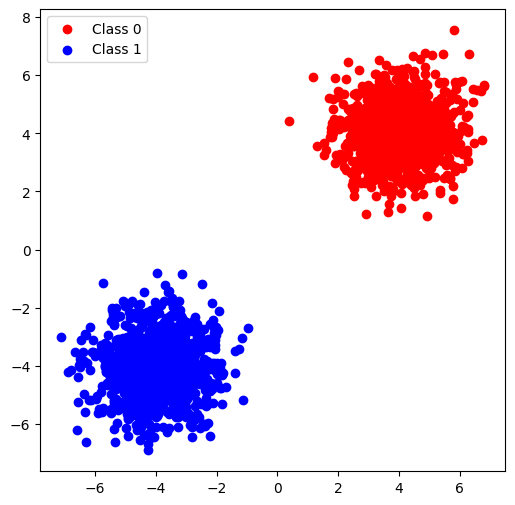

In [3]:
X, y, _ = load_bubbles()
visualize_data(X, y)

In [4]:
X_label1 = X[y == 1]
X_label0 = X[y == 0]

point_of_interest = np.array([[3, 3]])
point_closest_to_poi = X_label0[np.argmin(np.linalg.norm(X_label0 - point_of_interest, axis=1))]
point_of_interest, point_closest_to_poi

(array([[3, 3]]), tensor([2.9690, 2.9777]))

In [5]:
def weber_iteration(cf_points, max_steps):
    """Perform Weber iteration for counterfactual points.

    Args:
        cf_points (np.ndarray): Counterfactual points. shape (n_points, n_features).
        max_steps (int): Maximum number of steps for the iteration.
    """
    omega = np.zeros_like(cf_points[0])
    for step in range(max_steps):
        distance_omega_cf = np.linalg.norm(cf_points - omega, axis=1)
        denominator = 1 / (distance_omega_cf + 1e-8)
        nominator = np.sum(cf_points * denominator[:, np.newaxis], axis=0)
        omega = nominator / np.sum(denominator)
    return omega

In [6]:
from carla.recourse_methods import GrowingSpheres, Clue, Dice, Face
from carla import MLModel
from sklearn.ensemble import RandomForestClassifier
from synthetic_to_carla import Synthetic_CARLA

dataset = Synthetic_CARLA("bubbles")

class SKLCARLA(MLModel):
    def __init__(self, dataset, sklearn_model):
        super().__init__(dataset)
        self.dataset = dataset
        self.input_order = dataset.continuous

        self.sklearn_model = sklearn_model

    # List of the feature order the ml model was trained on
    @property
    def feature_input_order(self):
        return self.input_order

    # The ML framework the model was trained on
    @property
    def backend(self):
        return "pytorch"

    # The black-box model object
    @property
    def raw_model(self):
        return self.sklearn_model

    # The predict function outputs
    # the continuous prediction of the model
    def predict(self, x):
        return self.sklearn_model.predict(x)

    # The predict_proba method outputs
    # the prediction as class probabilities
    def predict_proba(self, x):
        if x.shape[-1] != len(self.input_order):
            x = x[self.input_order]
        
        
        if hasattr(self.sklearn_model, "predict_proba"):
            return self.sklearn_model.predict_proba(x)
        else:
            raise NotImplementedError(
                "The model does not implement the predict_proba method."
            )


tree_model = RandomForestClassifier(n_estimators=100, random_state=42)
tree_model.fit(X, y)
model = SKLCARLA(dataset, tree_model)

gs = GrowingSpheres(model)
clue = Clue(dataset, model)
dice = Dice(model)
fa = Face(model, {"mode": "knn", "fraction": 0.2})

[INFO] 
Net: [utils.py __init__]
[INFO] VAE_gauss_net [fc_gauss_cat.py __init__]
[INFO] Total params: 0.00M [fc_gauss_cat.py create_net]
[INFO] 
Network: [train.py train_VAE]
[INFO] 
Train: [train.py train_VAE]
[INFO] init cost variables: [train.py train_VAE]
[INFO] it 0/10, vlb -38.351752,  [train.py train_VAE]
[INFO] time: 0.205542 seconds
 [train.py train_VAE]
[INFO] vlb -37.581112 (-inf)
 [train.py train_VAE]
[INFO] Writting /Users/santothies/carla/models/autoencoders/clue/fc_VAE_None_models/theta_best.dat
 [utils.py save]
[INFO] it 1/10, vlb -36.813875,  [train.py train_VAE]
[INFO] time: 0.057484 seconds
 [train.py train_VAE]
[INFO] vlb -36.666214 (-37.581112)
 [train.py train_VAE]
[INFO] Writting /Users/santothies/carla/models/autoencoders/clue/fc_VAE_None_models/theta_best.dat
 [utils.py save]


/Users/santothies/Desktop/Masterthesis/carla/recourse_methods/catalog/clue/library/clue_ml/src/radam.py:55: UserWarning: This overload of addcmul_ is deprecated:
	addcmul_(Number value, Tensor tensor1, Tensor tensor2)
Consider using one of the following signatures instead:
	addcmul_(Tensor tensor1, Tensor tensor2, *, Number value = 1) (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/python_arg_parser.cpp:1691.)
  exp_avg_sq.mul_(beta2).addcmul_(1 - beta2, grad, grad)


[INFO] it 2/10, vlb -35.380735,  [train.py train_VAE]
[INFO] time: 0.115044 seconds
 [train.py train_VAE]
[INFO] vlb -35.488314 (-36.666214)
 [train.py train_VAE]
[INFO] Writting /Users/santothies/carla/models/autoencoders/clue/fc_VAE_None_models/theta_best.dat
 [utils.py save]
[INFO] it 3/10, vlb -33.176756,  [train.py train_VAE]
[INFO] time: 0.087095 seconds
 [train.py train_VAE]
[INFO] vlb -33.479602 (-35.488314)
 [train.py train_VAE]
[INFO] Writting /Users/santothies/carla/models/autoencoders/clue/fc_VAE_None_models/theta_best.dat
 [utils.py save]
[INFO] it 4/10, vlb -30.802038,  [train.py train_VAE]
[INFO] time: 0.056956 seconds
 [train.py train_VAE]
[INFO] vlb -30.845931 (-33.479602)
 [train.py train_VAE]
[INFO] Writting /Users/santothies/carla/models/autoencoders/clue/fc_VAE_None_models/theta_best.dat
 [utils.py save]
[INFO] it 5/10, vlb -28.000616,  [train.py train_VAE]
[INFO] time: 0.064819 seconds
 [train.py train_VAE]
[INFO] vlb -27.026623 (-30.845931)
 [train.py train_VAE]


In [7]:
def poi_to_df(dataset, point_of_interest, label):
    """Convert point of interest to DataFrame."""
    poi = point_of_interest.flatten()
    
    poi_data = {
        feature: poi[i] for i, feature in enumerate(dataset.continuous)
    }
    poi_data["label"] = label
    
    return pd.DataFrame(
        [poi_data], columns=list(poi_data.keys())
    )

df_point_of_interest = poi_to_df(dataset, point_of_interest, 0)

In [8]:
def weber_based_counterfactuals(method,dataset, point_of_interest, label, max_steps=1000):
    """Generate counterfactuals using Weber iteration."""
    # Sample 10 points around the point of interest
    points = np.random.normal(
        loc=point_of_interest.flatten(),
        scale=0.1,
        size=(10, len(point_of_interest.flatten()))
    )

    df_points = pd.DataFrame(points, columns=dataset.continuous)
    df_points["label"] = label

    cf_points = method.get_counterfactuals(
        df_points
    )

    cf = weber_iteration(cf_points.values, max_steps)

    return cf

/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/Users/santothies/Desktop/Masterthesis/.venv/lib/python3.10/site-packages/sklearn/utils/validation.py:2732: UserWarning: X has feature names, but RandomForestClassifier was fitted without feature names
  warnings.warn(
/var/folders/r0/h4rkplrj2qldt4_b_tdjz3cc0000gn/T/ipykernel_53731/4148070298.py:21: UserWarning: To copy construct from a ten

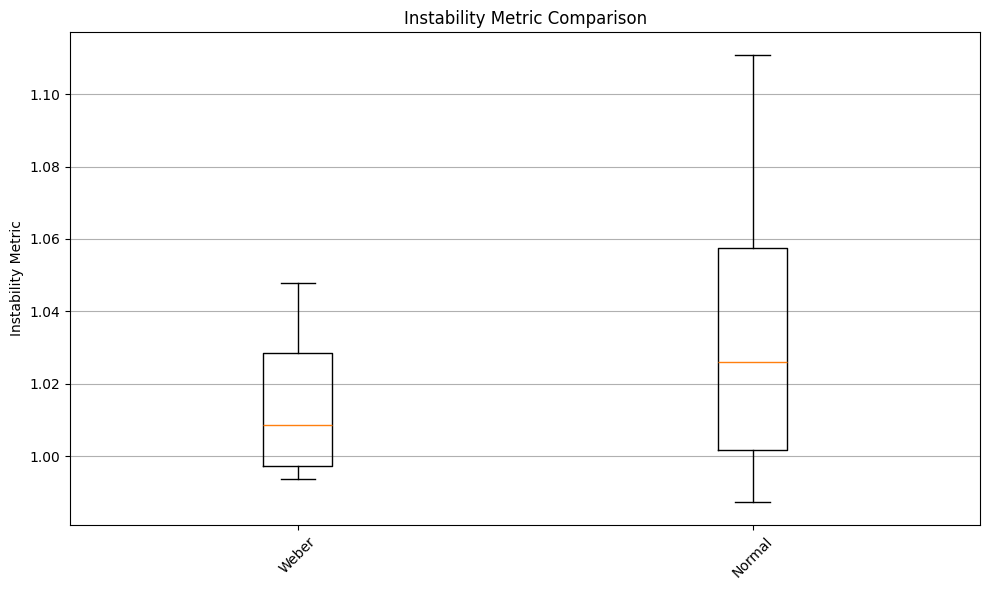

In [10]:
from property_procedures.utils import instability_metric


MAX_STEPS = 10_000

erg = []
for _ in range(10):
    cf_poi_weber = weber_based_counterfactuals(gs,dataset, point_of_interest, 0, MAX_STEPS)
    cf_closest_to_poi_weber = weber_based_counterfactuals(
        gs, dataset, point_closest_to_poi, 0, MAX_STEPS
    )
    cf_poi_normal = gs.get_counterfactuals(df_point_of_interest).values.astype(
        np.float32
    )
    cf_closest_to_poi_normal = gs.get_counterfactuals(
        poi_to_df(dataset, point_closest_to_poi, 0)
    ).values.astype(np.float32)

    instability_weber = instability_metric(
        point_of_interest=torch.tensor(point_of_interest),
        point_to_compare=torch.tensor(point_closest_to_poi),
        cf_point_of_interest=torch.tensor(cf_poi_weber),
        cf_point_to_compare=torch.tensor(cf_closest_to_poi_weber),
        X=torch.tensor(X),
    )
    instability_normal = instability_metric(
        point_of_interest=torch.tensor(point_of_interest),
        point_to_compare=torch.tensor(point_closest_to_poi),
        cf_point_of_interest=torch.tensor(cf_poi_normal),
        cf_point_to_compare=torch.tensor(cf_closest_to_poi_normal),
        X=torch.tensor(X),
    )
    erg.append([instability_weber.item(), instability_normal.item()])

erg = np.array(erg)
# Boxplot the results
plt.figure(figsize=(10, 6))
plt.boxplot(erg, labels=["Weber", "Normal"])
plt.title("Instability Metric Comparison")
plt.ylabel("Instability Metric")
plt.xticks(rotation=45)
plt.grid(axis='y')
plt.tight_layout()
plt.show()